[ Info: Waiting for another process (pid: 33788) to finish precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]. Pidfile: C:\Users\Odysseus\.julia\compiled\v1.12\Plots\ld3vC_1FvQA.ji.pidfile

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :

The true beta: [1, -1, 2]
The estimated bias: 

MethodError while trying to print a failed Task notice; giving up


[-0.00644683432384352, -0.003780736958104436, -0.0018663321650347342]
The estimated Variance: [0.0194735096445997, 0.023071860219209296, 0.022204251420231896]


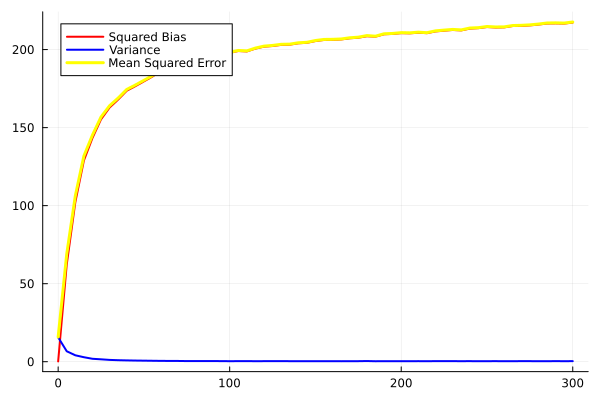

In [35]:
using LinearAlgebra
using Random
using Statistics
using Distributions
using Plots


includet("ridge-regression.jl")


# A simple sanity check
m = 500
n = 50
beta = [1,-1,2]
d = 3
sigma = 1
Sigma = I(d)
y = 0

bias, var_beta = mc_ridge(m,n,beta,sigma,Sigma,y) 
println("The true beta: ",beta)
println("The estimated bias: ",bias)
println("The estimated Variance: ",var_beta)



# 2.  bias / Variance trade-off plots
n= 50
d =15
m =100
sigma = 2
beta = randn(d)*5

rank_k = 2
A= randn(d,rank_k)
Sigma = A*A' +0.1*I
ytotal = 0:5:300

bias_square = []
variances = []
mses = []

for y in ytotal
    bias_vec,var_vec = mc_ridge(m,n,beta,sigma,Sigma,y)
    ssbias = sum(bias_vec.^2)
    ttvar =sum(var_vec)
    push!(bias_square,ssbias) 
    push!(variances,ttvar)
    push!(mses,ssbias+ttvar)
end

p = plot(ytotal,bias_square,label="Squared Bias",color =:red,lw =2)
plot!(p,ytotal,variances,label="Variance",color =:blue,lw =2)
plot!(p,ytotal,mses,label="Mean Squared Error",color =:yellow,lw =3)
display(p)